In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft
import time

function
$$ 
f(x) = e^{-50(x - 0.5)^2}
$$

Fourier tranform
$$
\hat{f} (k) = \exp{ \left[ \frac{ - k^2 - 100ik}{200} \right]} \sqrt{\frac{\pi}{50}}
$$

In [83]:
#Problem 1
#original function
def func(x):
    f = np.exp(-50*(x - 0.5)**2) 
    return f

#analytical result
def func_analytic(k):
    f = np.sqrt(np.pi/50) * np.exp( (-k**2 - 100*1j*k)/200 )
    return f

xgauss = np.linspace(0,1,200)
#k_fine = np.linspace(0, 2*np.pi, 100)
k_fine = np.linspace(-30,30,200)

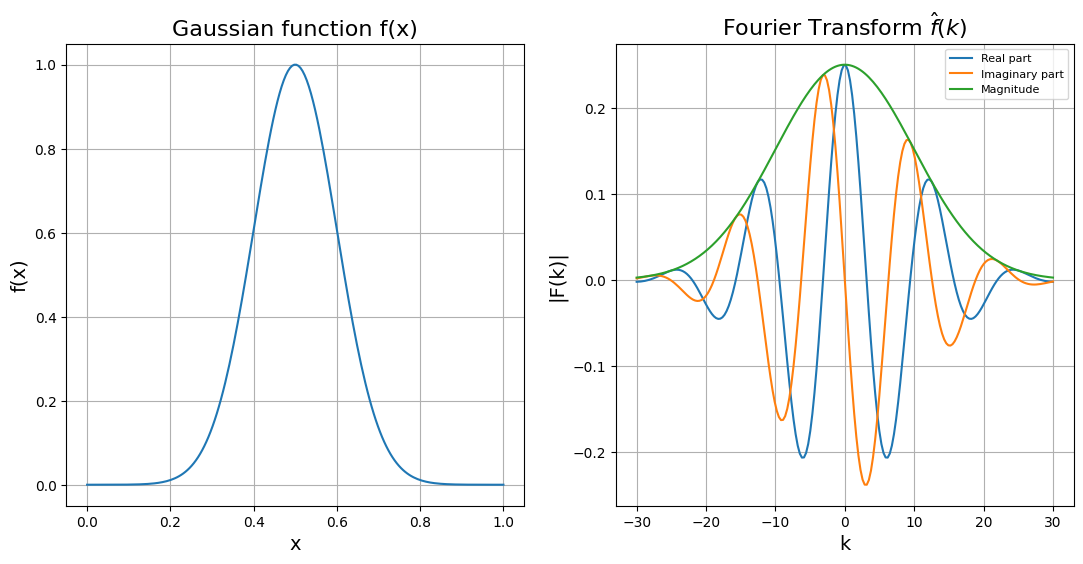

In [103]:
plt.figure(figsize=(13,6))
#plt.suptitle("Gaussian function", fontsize=18)
plt.subplot(1,2,1)
plt.title("Gaussian function f(x)", fontsize=16)
plt.plot(xgauss, func(xgauss), color='tab:blue')
#plt.legend(fontsize=12)
plt.xlabel('x', size=14)
plt.ylabel('f(x)', size=14)
plt.xticks(size=10)
plt.yticks(size=10)
plt.grid()

plt.subplot(1,2,2)
plt.title(r"Fourier Transform $\hat{f}(k)$", fontsize=16)
plt.plot(k_fine, np.real(func_analytic(k_fine)), color='tab:blue', label="Real part")
plt.plot(k_fine, np.imag(func_analytic(k_fine)), color='tab:orange', label="Imaginary part")
plt.plot(k_fine, np.abs(func_analytic(k_fine)), color='tab:green', label="Magnitude")
#plt.plot(k_fine, np.abs(func_analytic(k_fine)), 's-', ms=3, color='tab:green', label="Magnitude")
plt.legend(fontsize=8)
plt.xlabel('k', size=14)
plt.ylabel('|F(k)|', size=14)
plt.xticks(size=10)
plt.yticks(size=10)
plt.grid()

plt.savefig('HW05_Prob1_a.png', dpi=250, transparent=True)

DFT Formula
$$
X_k = \sum_{n=0}^{N-1} x_n e^{-i2 \pi \frac{k}{N}n } \\
x_n = \frac{1}{N} \sum_{k=0}^{N-1} X_k e^{i2 \pi \frac{k}{N}n }
$$

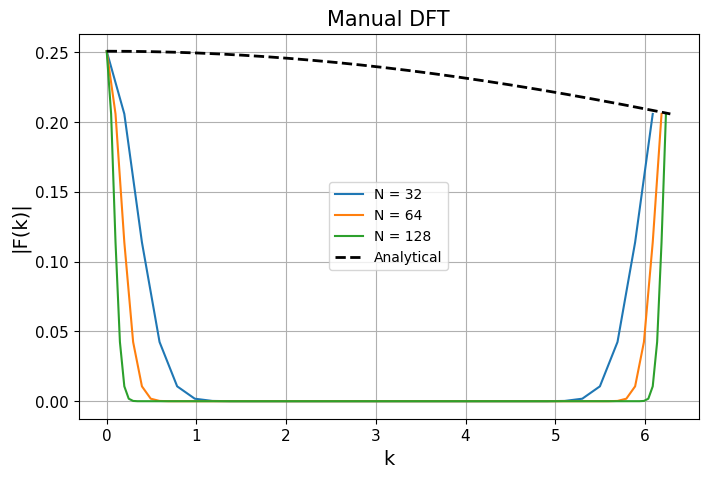

In [121]:
def dft(x):
    N = len(x)
    n = np.arange(N) #create a sequence of 0, 1, 2, 3,... according to Ns
    X = np.zeros(N, dtype=complex)

    for k in range(N):
        X[k] = np.sum(x * np.exp(-1j * 2*np.pi * k * n / N))

    return X

Ns = [32, 64, 128]

plt.figure(figsize=(8,5))
for N in Ns:
    # create a sequence of discrete points as a fraction, e.g. 1/32, 2/32, 3/32, ...
    seq = np.linspace(0, 1, N, endpoint=False)

    # and use it as an input for the gaussian
    x = func(seq) 
    
    # DFT calculation with x and N as inputs
    X = dft(x) 

    k_vals = 2 * np.pi * np.arange(N) / N
    X_scaled = (1 / N) * X

    plt.plot(k_vals, np.abs(X_scaled), label=f"N = {N}")
    #plt.plot(np.arange(N)/N, np.abs(X_scaled), label=f"N = {N}") #scaled down
    #plt.plot(np.arange(N)/N, np.abs(X), label=f"N = {N}")

k_fine2 = np.linspace(0, 2*np.pi, 500)
#k_fine2 = np.linspace(0, 1, 500)
plt.plot(k_fine2, np.abs(func_analytic(k_fine2)), 'k--', linewidth=2, label="Analytical")

plt.xlabel("k",size=14)
plt.ylabel("|F(k)|",size=14)
plt.xticks(size=11)
plt.yticks(size=11)
plt.title("Manual DFT", size=15)
plt.legend()
plt.grid(True)
#plt.show()

plt.savefig('HW05_Prob1_b.png', dpi=250, transparent=True)

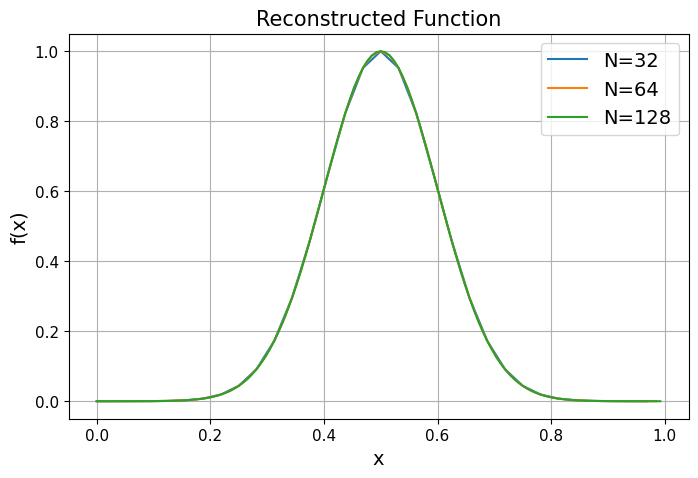

In [122]:
# Inverse DFT
def idft(X):
    N = len(X)
    k = np.arange(N)
    x_rec = np.zeros(N, dtype=complex)

    for n in range(N):
        x_rec[n] = (1/N) * np.sum(X * np.exp(1j * 2 * np.pi * k * n / N))

    return x_rec

# Try multiple N
#Ns = [32, 64, 128]

plt.figure(figsize=(8, 5))

for N in Ns:
    n = np.arange(N)
    x = func(n / N)

    X = dft(x)
    x_rec = idft(X)

    # Plot original vs reconstructed
    #plt.plot(n / N, x, '--', label=f"f(x), N={N}")
    plt.plot(n / N, np.real(x_rec), label=f"N={N}")

plt.xlabel("x",size=14)
plt.ylabel("f(x)",size=14)
plt.xticks(size=11)
plt.yticks(size=11)
plt.title("Reconstructed Function",size=15)
plt.legend(fontsize=14)
plt.grid(True)

#plt.show()

plt.savefig('HW05_Prob1_c.png', dpi=250, transparent=True)

In [53]:
g = 32
G = np.arange(g)
l = G/g
#print(G)

m = func(25 / 32)
print(m)

0.019157171837129137


In [92]:
def time_method(method, N, repeats=100):
    total = 0.0

    for _ in range(repeats):
        x = func(np.linspace(0, 1, N, endpoint=False))

        start = time.perf_counter()
        _ = method(x)
        end = time.perf_counter()

        total += (end - start)

    return total / repeats

Ns_dft = [2**j for j in range(3, 12)]
Ns_fft = [2**j for j in range(3, 21)]

dft_times = []
fft_times = []

for N in Ns_dft:
    t = time_method(dft, N, repeats=100)
    dft_times.append(t)

for N in Ns_fft:
    def fft_method(x):
        return fft(x)

    t = time_method(fft_method, N, repeats=100)
    fft_times.append(t)

DFT slope: 1.383
FFT slope: 0.714


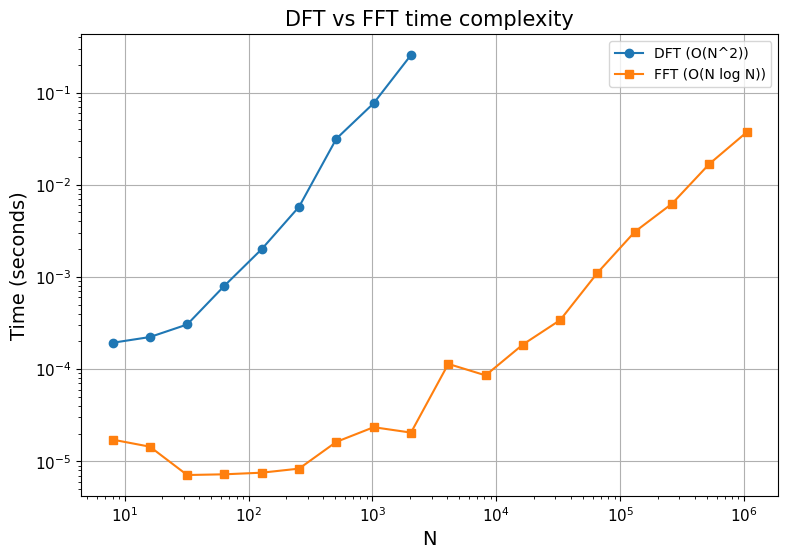

In [123]:
N_ref_dft = np.array(Ns_dft)
N_ref_fft = np.array(Ns_fft)
C1 = fft_times[0] / Ns_fft[0]**1
C2 = dft_times[0] / Ns_fft[0]**2
ref_slope1 = C1 * N_ref_fft**1
ref_slope2 = C2 * N_ref_dft**2

def compute_slope(Ns, times, name="method"):
    logN = np.log(Ns)
    logT = np.log(times)

    slope, intercept = np.polyfit(logN, logT, 1)

    print(f"{name} slope: {slope:.3f}")

    return slope
dft_slope = compute_slope(Ns_dft, dft_times, "DFT")
fft_slope = compute_slope(Ns_fft, fft_times, "FFT")

plt.figure(figsize=(9,6))

plt.loglog(Ns_dft, dft_times, 'o-', label=f"DFT (O(N^2))")
plt.loglog(Ns_fft, fft_times, 's-', label="FFT (O(N log N))")

#plt.loglog(N_ref_fft, ref_slope1, '--', label="m = 1")
#plt.loglog(N_ref_dft, ref_slope2, '--', label="m = 2")

plt.xlabel("N",size=14)
plt.ylabel("Time (seconds)",size=14)
plt.xticks(size=11)
plt.yticks(size=11)
plt.title("DFT vs FFT time complexity",size=15)
plt.legend()
plt.grid(True)
#plt.grid(True, which="both")
#plt.show()

plt.savefig('HW05_Prob1_d.png', dpi=250, transparent=True)

1D Heat equation
$$
\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}
$$
Initial condition
$$
u(x,0) = e^{ -50 \left( x - \frac{1}{2} \right)^2 }
$$
Transformation
$$
\frac{\partial \hat{u}}{\partial t} = - \alpha k^2 \hat{u}
$$

In [119]:
N = 64
T = 5
# Case 1
alpha1 = 0.005
dt1 = 0.001
# Case 2
alpha2 = 0.05
dt2 = 0.01

#Integrator
def rk4_step(u_hat, k, dt, alpha):
    def rhs(u_hat):
        return -alpha * (k**2) * u_hat

    k1 = rhs(u_hat)
    k2 = rhs(u_hat + 0.5 * dt * k1)
    k3 = rhs(u_hat + 0.5 * dt * k2)
    k4 = rhs(u_hat + dt * k3)

    return u_hat + (dt/6) * (k1 + 2*k2 + 2*k3 + k4)

def run_simulation(N, alpha, dt, T):
    x = np.linspace(0, 1, N, endpoint=False)

    # k values
    k = 2 * np.pi * np.arange(N) / N

    # initial condition
    u = np.exp(-50 * (x - 0.5)**2)
    u_hat = dft(u)

    steps = int(T / dt)

    snapshot_times = [0, 1, 2, 3, 4, 5]
    snapshot_steps = [int(ts / dt) for ts in snapshot_times]

    snapshots = {}
    heat_snapshots = {}

    for step in range(steps + 1):
        u_real = np.real(idft(u_hat))

        # total heat (integral ≈ sum * dx, dx = 1/N)
        total_heat = np.sum(u_real) / N

        if step in snapshot_steps:
            t = step * dt
            snapshots[t] = u_real.copy()
            heat_snapshots[t] = total_heat

        # RK4 step
        u_hat = rk4_step(u_hat, k, dt, alpha)

    return x, snapshots, heat_snapshots

x1, snapshots1, heat1 = run_simulation(N, alpha1, dt1, T)
x2, snapshots2, heat2 = run_simulation(N, alpha2, dt2, T)

print("=== Case 1 ===")
print(f"alpha = {alpha1}, dt = {dt1}")
print("Total heat at selected times:")
for ts in sorted(heat1.keys()):
    print(f"t = {ts:.1f}: {heat1[ts]:.6f}")

print("\n=== Case 2 ===")
print(f"alpha = {alpha2}, dt = {dt2}")
print("Total heat at selected times:")
for ts in sorted(heat2.keys()):
    print(f"t = {ts:.1f}: {heat2[ts]:.6f}")

=== Case 1 ===
alpha = 0.005, dt = 0.001
Total heat at selected times:
t = 0.0: 0.250663
t = 1.0: 0.250663
t = 2.0: 0.250663
t = 3.0: 0.250663
t = 4.0: 0.250663
t = 5.0: 0.250663

=== Case 2 ===
alpha = 0.05, dt = 0.01
Total heat at selected times:
t = 0.0: 0.250663
t = 1.0: 0.250663
t = 2.0: 0.250663
t = 3.0: 0.250663
t = 4.0: 0.250663
t = 5.0: 0.250663


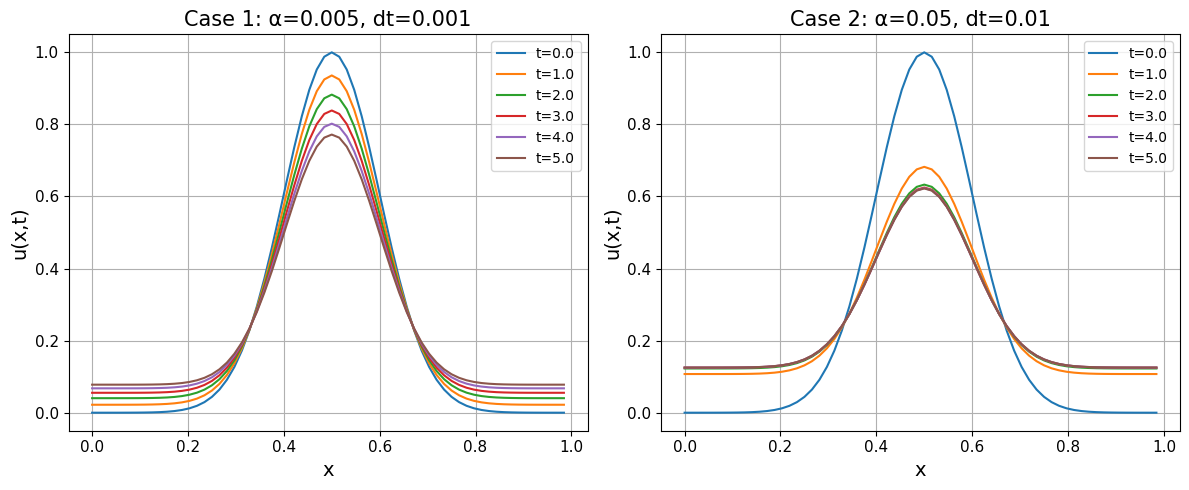

In [124]:
plt.figure(figsize=(12,5))

# LEFT: stable case
plt.subplot(1,2,1)
for t in sorted(snapshots1.keys()):
    plt.plot(x1, snapshots1[t], label=f"t={t:.1f}")

plt.title(f"Case 1: α={alpha1}, dt={dt1}",size=15)
plt.xlabel("x",size=14)
plt.ylabel("u(x,t)",size=14)
plt.xticks(size=11)
plt.yticks(size=11)
plt.legend()
plt.grid()

# RIGHT: unstable case
plt.subplot(1,2,2)
for t in sorted(snapshots2.keys()):
    plt.plot(x2, snapshots2[t], label=f"t={t:.1f}")

plt.title(f"Case 2: α={alpha2}, dt={dt2}",size=15)
plt.xlabel("x",size=14)
plt.ylabel("u(x,t)",size=14)
plt.xticks(size=11)
plt.yticks(size=11)
plt.legend()
plt.grid()

plt.tight_layout()
#plt.show()

plt.savefig('HW05_Prob2.png', dpi=250, transparent=True)